Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Reading in data

In [68]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# defining spherical harmonic degree cutoff
nmax_list = np.arange(5, 15, 2)

hankel=True
embedding_d=10

weight_flag = True

dmd_type_used = 'opdmd'

bopdmd=False
bopdmd_params = {
    "num_trials":50,
    "trial_size":0.9,
    "remove_bad_bags":True,
}

fbdmd = False

ensemble_flag = False

svd_rank_list = [-1, 0.9, 0.99, 0.999, 0.9999,2*len(mode_numbers), 0]
svd_rank_list = [int(val) for val in np.arange(10, 50, 4)]


## Running pipeline (loading data, run DMD, recover modes)

In [69]:
# BELOW:
# Runs pipeline and retrieves results for:
#   - specified nmax
#   - specified DMD setup
#   - specified SVD rank truncation

# -------------------------------------
# LOADING IN DATA
# -------------------------------------
# loading in all data to nmax = 15 (truncated in later use as necessary)
nmax_global = 15

# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax_global)

# Synthetic gauss coeffs
gnm_syn_ideal, gnm_syn, syn_suite_info = Synthetic_Full_SV_Record_Obtain(mode_numbers, times_used_relative, nmax=nmax_global)

# PREPARING DATA

# applying just to ideal synthetic record - equivalent to others
gnm_syn_non_wave = Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample)
gnm_syn_infilled = gnm_syn + gnm_syn_non_wave


def Pipeline_Run(nmax, svd_rank, ensemble_flag = False):

    # -------------------------------------
    # OBTAINING DMD MATCH RESULTS
    # -------------------------------------

    # now looping through pipeline
    # want: 1 ideal test, 1 resolved test, 1 background test, 100 noise ensembles.

    # PROJECTING DATA TO PHYSICAL SV GRID
    A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)

    results_dict = {}

    record_dict = {
        #"ideal":Truncate_Gauss_Coeffs(gnm_syn_ideal, tmax=nmax),
        "resolved":Truncate_Gauss_Coeffs(gnm_syn, tmax=nmax),
        #"background":Truncate_Gauss_Coeffs(gnm_syn_infilled, tmax=nmax)
    }

    for record_key in record_dict:

        record_used = record_dict[record_key]

        # projecting to physical space
        record_physical = A_r @ record_used.T

        # running DMD
        try:
            recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank,
                                        hankel, embedding_d, fbdmd, weighted=weight_flag)

            # matching input and output modes
            match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes, nmax=nmax)

            results_dict[record_key] = match_results

        except Exception:
            results_dict[record_key] = False


    # -------------------------------------
    # ENSEMBLE RESULTS
    # -------------------------------------

    if ensemble_flag:

        n_ensembles = 30

        perturbation_path = (
            Path(CHAOS_COV_DIR)
            / (
                "CHAOS_0806_nmax15_SV_nTyr_perturbations_N1000_Nt53.h5"
            )
        )

        ensemble_results = {}

        for mode_key in syn_suite_info:
            ensemble_results[mode_key] = {
                "period_error":[],
                "similarity":[],
                "no_match_count":0,
            }

        with h5py.File(perturbation_path, "r") as f:

            for i in tqdm(range(n_ensembles), desc="ensembles"):

                gnm_perturbation_i = f["perturbations"][i, :, :].T

                # truncating to nmax
                gnm_perturbation_i = Truncate_Gauss_Coeffs(gnm_perturbation_i, tmax=nmax)
                gnm_perturbed_i = Truncate_Gauss_Coeffs(gnm_syn, tmax=nmax) + gnm_perturbation_i

                # projecting to physical space
                record_physical = A_r @ gnm_perturbed_i.T

                try:
                    # running DMD
                    recovered_modes = Run_DMD(record_physical, times_used_relative, dmd_type_used, svd_rank, hankel, embedding_d, fbdmd, weighted=weight_flag)

                    # matching input and output modes
                    match_results = Match_Input_Output_Modes(syn_suite_info, recovered_modes, nmax=nmax, record_key='ensemble')

                    for mode_key in match_results:
                        if match_results[mode_key]:
                            ensemble_results[mode_key]["period_error"].append(match_results[mode_key]["period_error"])
                            ensemble_results[mode_key]["similarity"].append(match_results[mode_key]["similarity"])
                        else:
                            ensemble_results[mode_key]["no_match_count"] += 1
                except:
                    ensemble_results[mode_key] = False

        results_dict["ensemble"] = ensemble_results

    return(results_dict)


In [70]:
print(svd_rank_list)

[10, 14, 18, 22, 26, 30, 34, 38, 42, 46]


In [71]:


svd_rank_list = [-1, 0.99, 0.999, 0.9999, 0.99999,2*len(mode_numbers), 0, 25]

total_results = np.zeros((len(svd_rank_list), len(nmax_list)))

for i, svd_rank in tqdm(enumerate(svd_rank_list), desc="running ranks"):
    for j, nmax in enumerate(nmax_list):
        print(f"running {i, j}")
        results_run = Pipeline_Run(nmax, svd_rank)
        if results_run["resolved"]:
            match_count = results_run["resolved"]["match_count"]
            total_results[i, j] = match_count
        else:
            total_results[i, j] = np.nan

running ranks: 0it [00:00, ?it/s]

running (0, 0)


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1053174.425972805. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 2.42895898e+00+3.95749491e+01j  2.42733743e+00-3.96520436e+01j
 -6.62086427e-01+2.25460655e+01j -6.62086427e-01-2.25460655e+01j
 -1.71643920e-01+1.32060584e+01j -1.71643920e-01-1.32060584e+01j
 -9.87567954e-03+1.05477689e+01j -9.87175734e-03-1.05477739e+01j
  9.53494728e-02+9.00558451e+00j  9.52867177e-02-9.00550629e+00j
 -3.51348498e+09+3.53413867e+08j -7.20828442e+09-3.57433559e+08j
 -8.15910859e-02+6.44441979e+00j -8.15910859e-02-6.44441979e+00j
 -4.35025616e-02+5.18026607e+00j -4.35023343e-02-5.18026607e+00j
 -1.19645784e-02+4.22604853e+00j -1.19636689e-02-4.22604807e+00j
 -6.93730624e-01-2.82821125e-01j -1.55270635e+09+5.052960

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 694504.6129792542. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


...

running ranks: 6it [00:11,  1.49s/it]

running (6, 0)
running (6, 1)
running (6, 2)
running (6, 3)
running (6, 4)


running ranks: 7it [00:14,  1.94s/it]

running (7, 0)
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 1.94083248e+09-9.21498310e+08j -8.47191884e+08+2.86113926e+08j
  4.60478683e+09+9.10427335e+09j  2.68052182e+08+8.43145888e+07j
  2.62113696e+00+8.30777530e-01j  2.57658435e+00-9.79220496e-01j
  2.97028356e+07-2.73159711e+07j  2.81884854e+07+2.87497167e+07j
  4.30725071e-02-1.31921865e-03j  6.14935559e+08+6.53440928e+08j
  6.13988116e+08-6.51750282e+08j  2.54761309e+09+5.36316819e+09j
  2.54203092e+09-5.35847679e+09j -1.47061422e+09+2.26064615e+09j
 -1.47040207e+09-2.26158459e+09j -1.21165748e+09+8.75037773e+08j
 -1.21046882e+09-8.76816645e+08j -5.46430203e+08+9.68949252e+06j
 -5.46097373e+08-1.25813537e+07j  3.666568

running ranks: 8it [00:17,  2.21s/it]


In [72]:
print(total_results)

[[nan nan  0. nan  0.]
 [ 0.  2.  3.  3.  4.]
 [ 1.  4.  4.  4.  5.]
 [ 0.  4.  5.  5.  5.]
 [ 4.  4.  5.  5.  4.]
 [ 4.  4.  4.  5.  4.]
 [ 4.  4.  5.  4.  4.]
 [nan  4.  5.  5.  4.]]


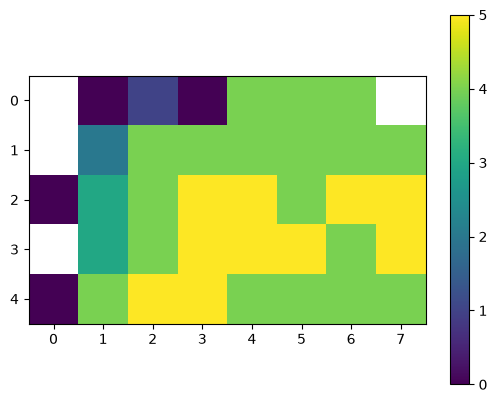

In [73]:
plt.imshow(total_results.T)
plt.colorbar()
plt.show()

## Comparing recovery success


In [81]:
# select best performing degree-rank combo and perform ensemble resolved analysis - show uncertainties etc.
results_dict = Pipeline_Run(10, 0.9999, ensemble_flag=True)

ensembles: 100%|██████████| 30/30 [00:19<00:00,  1.57it/s]


In [75]:
print(results_dict.keys())

dict_keys(['resolved', 'ensemble'])


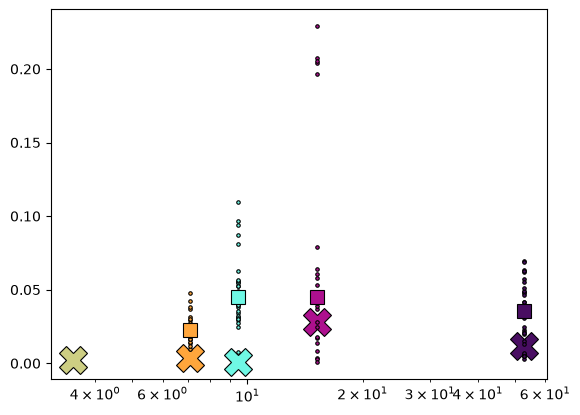

In [82]:
# looking at each record outcomes
plot_rules = {
    "ideal":{
        "shape":"o",
        "size":10,
    },
    "resolved":{
        "shape":"X",
        "size":20,
    },
    "background":{
        "shape":"^",
        "size":20,
    },
    "ensemble":{
        "shape":".",
        "size":5,
    }
}

mode_colours = {}
rng = np.random.default_rng(5)

for mode_key in mode_numbers:

    random_colour = rng.random(3)
    mode_colours[mode_key] = random_colour

for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        period_error, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(period_error), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')




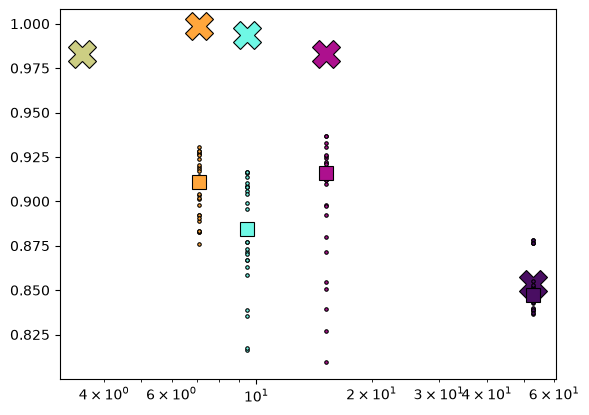

In [83]:

for result_type in results_dict:

    result_info = results_dict[result_type]

    for mode_key in mode_numbers:

        mode_info = syn_suite_info[mode_key]
        period = mode_info["true_period"]
        mode_result = result_info[mode_key]

        if mode_result:

            if result_type == "ensemble":

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]
                num_unmatched = mode_result["no_match_count"]

                period_plot = period * np.ones_like(period_error)

            else:

                period_error = mode_result["period_error"]
                similarity = mode_result["similarity"]

                period_plot = period

            plot_rule = plot_rules[result_type]

            plt.semilogx(period_plot, 
                        similarity, 
                        color=mode_colours[mode_key], 
                        marker=plot_rule["shape"], 
                        ms=plot_rule["size"], 
                        markeredgecolor="black",
                        markeredgewidth=0.8,
                        linestyle=' ')

            if result_type == "ensemble":
                plt.semilogx(period, 
                            np.median(similarity), 
                            color=mode_colours[mode_key], 
                            marker="s", 
                            ms=10, 
                            markeredgecolor="black",
                            markeredgewidth=0.8,
                            linestyle=' ')